<a href="https://colab.research.google.com/github/elo-meriem/STAT-7220-Applied-Experimental-Design/blob/main/Assignments/HW2/HW-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "elo-meriem"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "elo-meriem" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Comparative Experiments"
today_dir = "Assignments"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/elo-meriem/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
⚠️ WARNING: You are working in the instructor's repo, not your fork!
💡 Please fork the repo to your own account and update `github_username` above.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

determine whether there are significant differences in quiz performance among undergraduate students taught using three different teaching methods:

**Question 2.** Specify the outcome variable

the students score on the 50-question hypothesis testing quiz

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

independent variable:teaching methods, This is a categorical variable with three levels :(1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups)

lurking variables: Prior Knowledge a given student has about hypothesis testing : categorized into "High" and "Low"

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

Completely randomized design would not be appropriate because the groups are not homogeneous in terms of prior knowledge. That is why we are using a randomized block design instead, to control for differences in prior knowledge

**Question 5.** State the null and alternative hypotheses for this experiment.

H0:μ1=μ2=⋯=μt

H1:At least one pair of group means are not equal

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

the mean score tends to increase within each Teaching_method categorie as we move from traditional method to Inquiry-Based Learning to Collaborative Learning.

additionally, within the each teaching method, it looks like score tends to increase from low to high prior knowledge.

therfore the results support the alternative hypothesis



In [3]:
## Import Appropriate Libraries ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Data ##

teaching_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Data Science Teaching Method.xlsx")

## Data Integrity Check ##

print(teaching_data.info())

## Calculate Means and Standard Deviations
## by Prior_Knowledge and Teaching_Method ##

sum_stats = teaching_data.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean','std'])

print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114


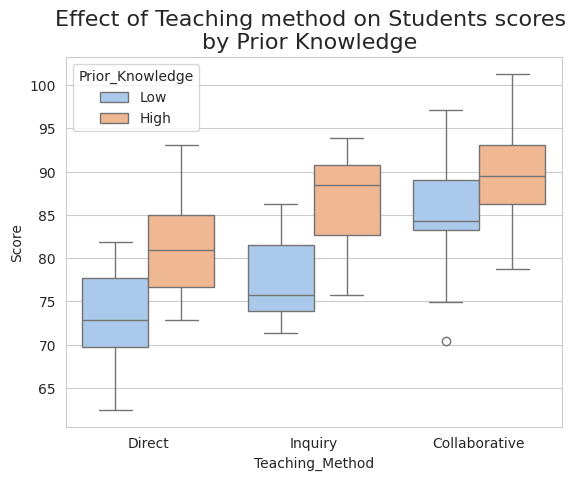

In [16]:
sns.set_style("whitegrid")

sns.boxplot(
    data=teaching_data,
    x='Teaching_Method',
    y='Score',
    hue='Prior_Knowledge',
    palette='pastel' # Choose a color palette
)

## Step 3: Add labels and titles ##

plt.title("Effect of Teaching method on Students scores \nby Prior Knowledge ",
          loc='center',
          fontsize=16)

## Show the plot ##

plt.show()

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



In [4]:
## Fit ANOVA Model ##

#fit the model:

ex_mod = ols("Score~Teaching_Method+Prior_Knowledge",data=teaching_data).fit()

## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Teaching method
## is evaluated after adjusting for Prior knowledge ##

ex_tab = sm.stats.anova_lm(ex_mod,typ=3)

## Add Significance Column ##

ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Print Only Treatment & BMI Rows ##

print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


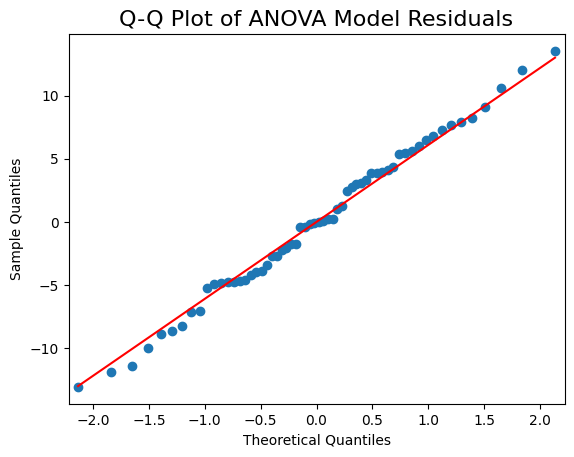

Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed (fail to reject H0).


In [5]:
#Assumption checks:
## Assessing Normality ##

## Import scipy ##

import scipy.stats as stats

## Extract Model Residuals ##

ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

From the results of our visual and testing method of evaluating the normality assumption, we can see that the data support the assumption of normality given that:

The points in the QQ-plot all generally fall along the line bisecting the plot with little deviation, and
The p-value associated with the Shapiro-Wilk Test of Normality gives evidence for the null hypothesis of normality.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?






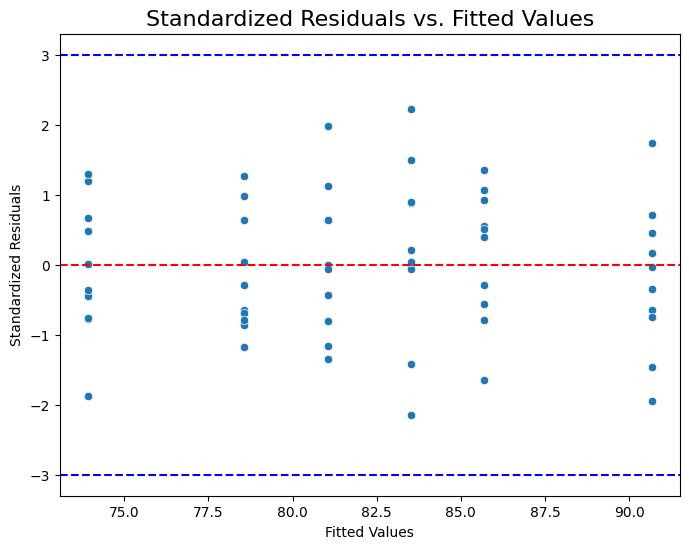

F-statistic: 0.7579465871345045
F p-value: 0.5224437459616452
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [6]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

Here, we can also see that our visual and testing method support the assumption of constant variance of the residuals. This is because:

- In the scatterplot, the points are all randomly scattered about 0, which suggests that 0 may be a reasonable estimate for the mean of the residuals.

- Also in the scatterplot, the heights of the vertical lines are all approximately the same.

- The p-value associated with the B-P test statistic indicates that the data more strongly support the null hypothesis of constant variance.
Perfect! So since our assumption are reasonbly supported by the data, we can feel confident in interpreting the results:

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

In [10]:
## Print ANOVA Table Again ##

print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])


                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


since F(2, 57) = 11.63, p = 0.00006 <0.001 , we would say that our data more strongly support the alternative hypothesis for the test of the main effect.

In context, this suggests that the differences in mean scores observed between the teachning method group may be statistically meaningful.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


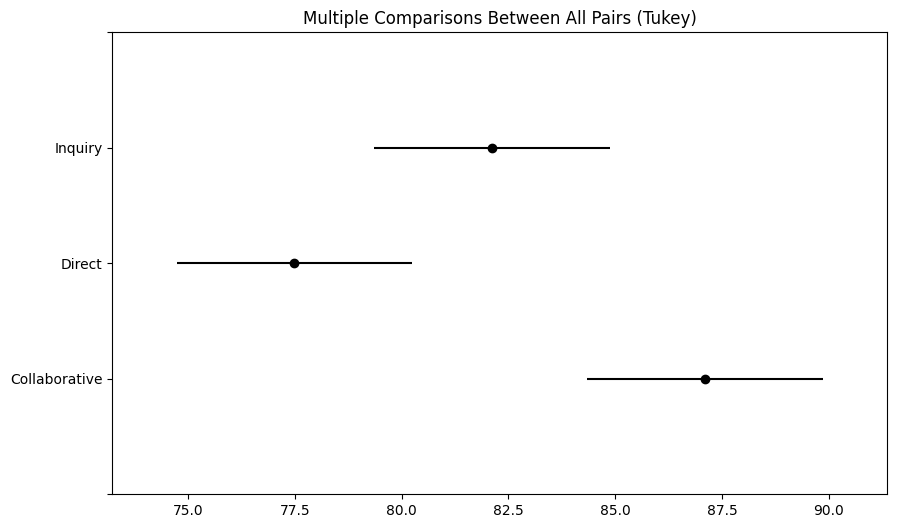

In [11]:
## Import pairwise_tukeyhsd function ##

from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test  ##

tukey_result = pairwise_tukeyhsd(endog=teaching_data['Score'], groups=teaching_data['Teaching_Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(tukey_result.plot_simultaneous())

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.



we can see that all of the p-values are less than 0.05, which would indicate that all the Score group means may differ substantially from each other in this population, controlling for Prior knowledge.

students in the collaborative learning group had the greatest group score, followed by Inquiry-Based Learning, and then Direct Instruction.

These results suggest that Collaborative Learning may be an effective teaching method for improving learning outcomes and achieving higher scores, regardless of students’ prior knowledge.



**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

The objective of this study is to compare the mean student engagement (measured by total logins) across the four online learning platforms (A, B, C, D) while controlling for Day of the Weekand and Time of Day for students enrolled in an undergraduate online synchronous data science course

**Question 2.** Specify the outcome variable

the mean student engagement (measured by total logins)

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

independent variable : the online platforms (A,B,C,D)

blocking factors: day of the week and time of day

possible lurking variables:
- Students who have full/part jobs at the time of the class.
- Students who only have access to a campus computer may be unable to - participate in evening
Internet connectivity quality


**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

In this case, we have a treatment factor (online platform A, B, C, D) and two blocking factors (Day of the Week and Time of Day); therefore, a Latin Square Design (LSD) would be appropriate. In a Completely Randomized Design (CRD), we do not account for any blocking factors, and in a Randomized Block Design (RBD), we can control for only one blocking factor. Therefore, LSD is the most suitable choice here because it allows us to control for both blocking factors while comparing the effects of the online platform

**Question 5.** State the null and alternative hypotheses for this experiment.

H0H1:μ1=μ2=⋯=

μt:At least two group means differ

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?


In [13]:
## Import Necessary Packages ##
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Read in Latin Square Dog Toys Data ##

online_learning_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/Online Learning and Engagement.xlsx")

## Data Integrity Check ##

print(online_learning_data.info())

## Calcualte Means and Standard Deviations ##

sum_stats = online_learning_data.groupby("Platform")["Engagement"].agg(['mean','std'])

print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Day         16 non-null     object 
 1   Section     16 non-null     object 
 2   Platform    16 non-null     object 
 3   Engagement  16 non-null     float64
dtypes: float64(1), object(3)
memory usage: 644.0+ bytes
None
               mean        std
Platform                      
A         1408.8475  19.319733
B         1339.7200  39.845434
C         1332.6425  32.288451
D         1379.0225   7.354601


From these results, it looks like Platform A provides the highest student engagement compared to the other platforms. We can see that:

- the difference between A and B is about 69, which is roughly 1.7σ.

- The difference between A and C is about 76, which is roughly 2.4σ.

- The difference between A and D is about 30, which is roughly 3.9σ.

- Finally, the difference between B and C is about 7, which is roughly 0.2σ.

Therefore, Platform A appears to generate noticeably higher engagement, while the differences among B, C, and D are smaller

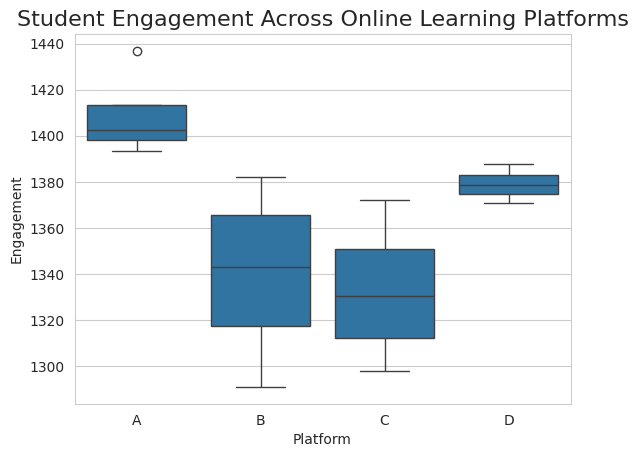

In [14]:
## Build a Boxplot ##

## Set up style ##

sns.set_style("whitegrid")

## Specify Aesthetics ##

sns.boxplot(
    data=online_learning_data,
    x='Platform',
    y='Engagement'
)

## Add labels and titles ##

plt.title("Student Engagement Across Online Learning Platforms",
          loc='center',
          fontsize=16)

## Show the plot ##

plt.show()

Question 7. Build a three-way ANOVA model. Test the assumption of normality using both a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

In [ ]:
## Fit ANOVA Model ##

lsd_mod = ols("PSI~Formulation+Machine+Operator",data=online_learning_data).fit()

## Extract Residuals ##

residuals = lsd_mod.resid

## Plot QQ-Plot with seaborn ##

sm.qqplot(residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals\nLatin Square Design - Dog Toy Durability Test",
          loc='center',
          fontsize=16)
plt.show()

## S-W Test ##

sw = stats.shapiro(residuals)

## Extract Test Stat & p-value ##
sw_stat = sw.statistic
sw_pval = sw.pvalue
print(f"Shapiro-Wilk Test Statistic: {sw_stat:.4f}, p-value: {sw_pval:.4f}")
if sw_pval > 0.05:
    print("✅ Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("❌ Residuals do not appear to be normally distributed (reject H0).")

Question 8. Test the assumption of homogeneity of variance using both a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

Question 9. Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

Question 10. If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

Question 11. Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.